In [ ]:
# Cell 1: Setup

import tensorflow as tf
from tensorflow import keras                # type: ignore
from tensorflow.keras import layers         # type: ignore
import numpy as np
import matplotlib.pyplot as plt

# GPU configuration for better performance and stability
gpus = tf.config.list_physical_devices('GPU')
if gpus:
    tf.config.experimental.set_memory_growth(gpus[0], True)
    tf.config.optimizer.set_jit(True)

print(f"TensorFlow version: {tf.__version__}")
print(f"GPU Available: {tf.config.list_physical_devices('GPU')}")

np.random.seed(42)
tf.random.set_seed(42)

# CIFAR-10
(x_train, y_train), (x_test, y_test) = keras.datasets.cifar10.load_data()

x_train = x_train.astype("float32") / 255.0
x_test  = x_test.astype("float32") / 255.0

y_train = y_train.flatten()
y_test  = y_test.flatten()

BATCH_SIZE = 128
EPOCHS = 10
NUM_CLASSES = 10

2026-05-01 02:18:54.398592: I tensorflow/core/util/port.cc:153] oneDNN custom operations are on. You may see slightly different numerical results due to floating-point round-off errors from different computation orders. To turn them off, set the environment variable `TF_ENABLE_ONEDNN_OPTS=0`.
2026-05-01 02:18:54.581830: I tensorflow/core/platform/cpu_feature_guard.cc:210] This TensorFlow binary is optimized to use available CPU instructions in performance-critical operations.
To enable the following instructions: AVX2 AVX512F AVX512_VNNI AVX512_BF16 FMA, in other operations, rebuild TensorFlow with the appropriate compiler flags.
2026-05-01 02:18:56.414822: I tensorflow/core/util/port.cc:153] oneDNN custom operations are on. You may see slightly different numerical results due to floating-point round-off errors from different computation orders. To turn them off, set the environment variable `TF_ENABLE_ONEDNN_OPTS=0`.


TensorFlow version: 2.20.0
GPU Available: [PhysicalDevice(name='/physical_device:GPU:0', device_type='GPU')]


/home/username/tf-env/lib/python3.12/site-packages/keras/src/datasets/cifar.py:18: VisibleDeprecationWarning: dtype(): align should be passed as Python or NumPy boolean but got `align=0`. Did you mean to pass a tuple to create a subarray type? (Deprecated NumPy 2.4)
  d = cPickle.load(f, encoding="bytes")


In [ ]:
# Cell 2: Hebbian Conv (w/Oja)

class HebbianConv2D(tf.keras.layers.Layer):

    def __init__(self, filters, lr=0.0005):
        super().__init__()
        self.filters = filters
        self.lr = lr

    def build(self, input_shape):

        self.w = self.add_weight(
            shape=(3, 3, input_shape[-1], self.filters),
            initializer="random_normal",
            trainable=False
        )

    def call(self, x):

        # forward pass
        y = tf.nn.conv2d(x, self.w, strides=1, padding="SAME")
        y = tf.nn.relu(y)

        patches = tf.image.extract_patches(
            images=x,
            sizes=[1, 3, 3, 1],
            strides=[1, 1, 1, 1],
            rates=[1, 1, 1, 1],
            padding="SAME"
        )

        patches = tf.reshape(patches, [-1, 3 * 3 * x.shape[-1]])
        outputs = tf.reshape(y, [-1, self.filters])

        # Hebbian correlation
        hebb = tf.matmul(patches, outputs, transpose_a=True)
        hebb = hebb / (tf.cast(tf.shape(patches)[0], tf.float32) + 1e-8)

        # reshape to kernel shape
        hebb = tf.reshape(hebb, self.w.shape)


        # Stability fixes?

        # normalise update
        delta_w = hebb - 0.01 * self.w
        delta_w = delta_w / (tf.norm(delta_w) + 1e-8)

        # apply small step
        self.w.assign_add(self.lr * delta_w)

        # hard clip (prevents NaNs)
        self.w.assign(tf.clip_by_value(self.w, -0.5, 0.5))

        return y

In [3]:
# Cell 3: Hebbian Encoder (feature extractor)

class HebbianEncoder(tf.keras.Model):

    def __init__(self):
        super().__init__()

        self.conv1 = HebbianConv2D(32)
        self.conv2 = HebbianConv2D(64)
        self.conv3 = HebbianConv2D(128)

        self.pool = layers.AveragePooling2D(2)
        self.flatten = layers.Flatten()

    def call(self, x):

        x = self.conv1(x)
        x = self.pool(x)

        x = self.conv2(x)
        x = self.pool(x)

        x = self.conv3(x)

        x = self.flatten(x)

        return x

In [4]:
# Cell 4: Reinforcement-style readout head

class Readout(tf.keras.Model):

    def __init__(self):
        super().__init__()

        self.dense = layers.Dense(NUM_CLASSES)

    def call(self, x):
        return self.dense(x)

In [5]:
# Cell 5: Hybrid Model

class HybridModel(tf.keras.Model):

    def __init__(self):
        super().__init__()

        self.encoder = HebbianEncoder()
        self.readout = Readout()

    def call(self, x, training=False):

        features = self.encoder(x)
        logits = self.readout(features)

        return logits

In [6]:
# Cell 6: Training loop (Hybrid Learning)

model = HybridModel()

optimizer = tf.keras.optimizers.AdamW(0.0001)

train_ds = tf.data.Dataset.from_tensor_slices((x_train, y_train))
train_ds = train_ds.shuffle(10000)
train_ds = train_ds.map(lambda x, y: (x, tf.cast(y, tf.int32)))
train_ds = train_ds.batch(128)

test_ds = tf.data.Dataset.from_tensor_slices((x_test, y_test))
test_ds = test_ds.map(lambda x, y: (x, tf.cast(y, tf.int32)))
test_ds = test_ds.batch(128)

for epoch in range(EPOCHS):

    print(f"\nEpoch {epoch+1}/{EPOCHS}")

    for step, (x, y) in enumerate(train_ds):

        with tf.GradientTape() as tape:

            logits = model(x, training=True)

            loss = tf.reduce_mean(
                tf.nn.sparse_softmax_cross_entropy_with_logits(
                    labels=y,
                    logits=logits
                )
            )

        # ONLY readout gets gradients
        grads = tape.gradient(loss, model.readout.trainable_weights)
        optimizer.apply_gradients(zip(grads, model.readout.trainable_weights))

        if step % 100 == 0:
            print(f"step {step} loss {loss.numpy():.4f}")

I0000 00:00:1777598342.632392  825109 gpu_device.cc:2020] Created device /job:localhost/replica:0/task:0/device:GPU:0 with 5560 MB memory:  -> device: 0, name: NVIDIA GeForce RTX 4060 Laptop GPU, pci bus id: 0000:01:00.0, compute capability: 8.9



Epoch 1/10


2026-05-01 02:19:06.221270: I external/local_xla/xla/stream_executor/cuda/cuda_dnn.cc:473] Loaded cuDNN version 91900


step 0 loss 2.2991
step 100 loss 2.2097
step 200 loss 2.1175
step 300 loss 2.0771


2026-05-01 02:19:18.526274: I tensorflow/core/framework/local_rendezvous.cc:407] Local rendezvous is aborting with status: OUT_OF_RANGE: End of sequence


...


Epoch 3/10
step 0 loss 1.7678
step 100 loss 1.9506
step 200 loss 1.8622
step 300 loss 1.9573

Epoch 4/10
step 0 loss 1.8027
step 100 loss 1.9687
step 200 loss 2.0381
step 300 loss 1.9994


2026-05-01 02:19:47.985331: I tensorflow/core/framework/local_rendezvous.cc:407] Local rendezvous is aborting with status: OUT_OF_RANGE: End of sequence



Epoch 5/10
step 0 loss 1.9622
step 100 loss 1.7474
step 200 loss 1.8080
step 300 loss 1.6501

Epoch 6/10
step 0 loss 1.8091
step 100 loss 1.9495
step 200 loss 1.8626
step 300 loss 1.8321

Epoch 7/10
step 0 loss 1.6952
step 100 loss 1.8149
step 200 loss 1.8364
step 300 loss 1.9471

Epoch 8/10
step 0 loss 2.1161
step 100 loss 2.0138
step 200 loss 2.1687
step 300 loss 1.7535


2026-05-01 02:20:28.932061: I tensorflow/core/framework/local_rendezvous.cc:407] Local rendezvous is aborting with status: OUT_OF_RANGE: End of sequence



Epoch 9/10
step 0 loss 1.8890
step 100 loss 2.0923
step 200 loss 2.1019
step 300 loss 2.2114

Epoch 10/10
step 0 loss 1.9425
step 100 loss 2.0494
step 200 loss 2.3785
step 300 loss 2.8250


TypeError: Invalid shape (10,) for image data

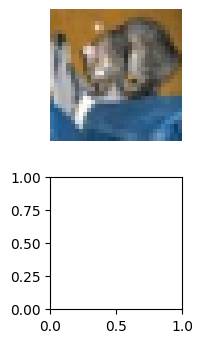

In [ ]:
#NOT WORKING Cell 7: Reconstruction visualiser (encoder + decoder models)

def show_reconstructions(model, dataset, n=8):

    x, _ = next(iter(dataset))
    x = x[:n]

    # forward pass depending on model structure
    if hasattr(model, "encoder") and hasattr(model, "decoder"):
        features = model.encoder(x, training=False)
        recon = model.decoder(features, training=False)
    else:
        # fallback: direct model output
        recon = model(x, training=False)

    x = x.numpy()
    recon = recon.numpy()

    plt.figure(figsize=(2*n, 4))

    for i in range(n):

        # original
        ax = plt.subplot(2, n, i+1)
        plt.imshow((x[i] + 1) / 2 if x.max() > 1 else x[i])
        plt.axis("off")

        # reconstruction
        ax = plt.subplot(2, n, i+1+n)
        plt.imshow((recon[i] + 1) / 2 if recon.max() > 1 else recon[i])
        plt.axis("off")

    plt.show()

show_reconstructions(model, test_ds)

In [ ]:
#NOT WORKING Cell 8: Generation visualisation (Hebbian feature activation sampling)

def show_generations(decoder, n=8):

    z = tf.random.normal((n, latent_dim))

    out = decoder(z, training=False)

    plt.figure(figsize=(2*n, 2))

    for i in range(n):

        img = out[i]
        img = tf.clip_by_value(img, -1, 1)
        img = (img + 1) / 2

        plt.subplot(1, n, i+1)
        plt.imshow(img)
        plt.axis("off")

    plt.show()

show_generations(model)

ValueError: Can't convert Python sequence with mixed types to Tensor.

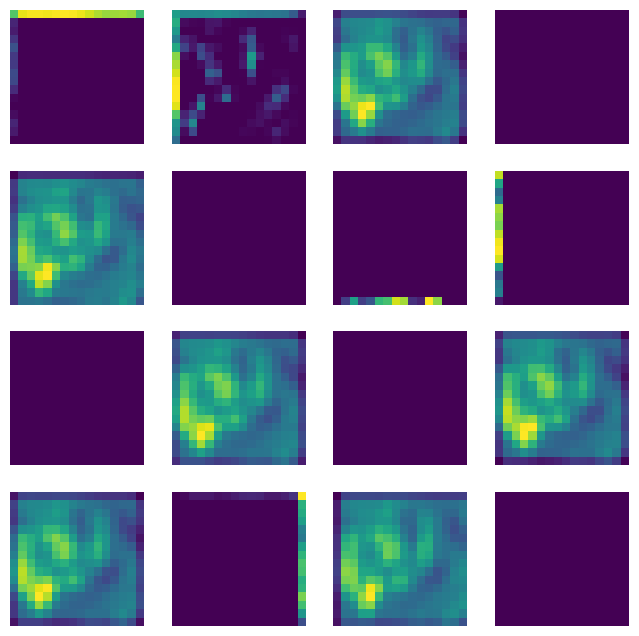

In [ ]:
# Cell 9: Hebbian feature map visualisation

def show_feature_maps(model, x):

    x = x[:1]

    h = x
    activations = []

    for layer in model.encoder.layers:
        h = layer(h)
        activations.append(h)

    # find LAST 4D tensor
    feat = None
    for a in reversed(activations):
        if len(a.shape) == 4:
            feat = a[0]
            break

    if feat is None:
        print("No convolutional feature map found.")
        return

    n = min(16, feat.shape[-1])

    plt.figure(figsize=(8,8))

    for i in range(n):
        plt.subplot(4, 4, i+1)
        plt.imshow(feat[:, :, i], cmap="viridis")
        plt.axis("off")

    plt.show()

x, _ = next(iter(test_ds))
show_feature_maps(model, x)

In [ ]:
# Cell 10: Test

x, _ = next(iter(test_ds))
out = model(x)

print(type(out))
print([o.shape for o in out] if isinstance(out, (list, tuple)) else out.shape)

<class 'tensorflow.python.framework.ops.EagerTensor'>
(128, 10)
